In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

In [15]:

# --- 1. CHARGEMENT ET RÉÉCHANTILLONNAGE ---
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00492/Metro_Interstate_Traffic_Volume.csv.gz"
df = pd.read_csv(url, compression='gzip')
df['date_time'] = pd.to_datetime(df['date_time'])
df = df.drop_duplicates(subset=['date_time'])
df = df.set_index('date_time').sort_index()

# On crée un index horaire complet pour boucher les trous
full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='H')
df = df.reindex(full_range)

# On remplit les valeurs manquantes par interpolation (pour le trafic et la météo)
df['traffic_volume'] = df['traffic_volume'].interpolate(method='linear')
df['temp'] = df['temp'].ffill()
# On remplit les autres colonnes catégorielles
df['holiday'] = df['holiday'].fillna('None')
df['weather_main'] = df['weather_main'].ffill()

/tmp/ipykernel_8156/2640356193.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='H')


In [16]:
# --- 2. FEATURE ENGINEERING AVANCÉ ---
df['hour'] = df.index.hour
df['day_of_week'] = df.index.dayofweek
df['month'] = df.index.month

# LAGS CRUCIAUX (C'est ici que le score explose)
df['lag_1h'] = df['traffic_volume'].shift(1)
df['lag_2h'] = df['traffic_volume'].shift(2)
df['lag_24h'] = df['traffic_volume'].shift(24)    # Hier à la même heure
df['lag_168h'] = df['traffic_volume'].shift(168)  # La semaine dernière à la même heure

# Moyenne glissante sur 24h
df['rolling_mean_24h'] = df['traffic_volume'].shift(1).rolling(window=24).mean()

# Suppression des NaNs créés par les lags de 168h
df.dropna(inplace=True)


In [17]:
df

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,traffic_volume,hour,day_of_week,month,lag_1h,lag_2h,lag_24h,lag_168h,rolling_mean_24h
2012-10-09 09:00:00,None,279.35,0.0,0.0,90.0,Clouds,overcast clouds,5599.0,9,1,10,5765.0,6449.0,4832.0,5545.0,3426.062500
2012-10-09 10:00:00,None,281.37,0.0,0.0,90.0,Clouds,overcast clouds,4534.0,10,1,10,5599.0,5765.0,4395.0,4516.0,3458.020833
2012-10-09 11:00:00,None,283.11,0.0,0.0,90.0,Clouds,overcast clouds,4691.0,11,1,10,4534.0,5599.0,4411.0,4767.0,3463.812500
2012-10-09 12:00:00,None,284.08,0.0,0.0,75.0,Clouds,broken clouds,5067.0,12,1,10,4691.0,4534.0,4648.0,5026.0,3475.479167
2012-10-09 13:00:00,None,285.14,0.0,0.0,75.0,Clouds,broken clouds,5030.0,13,1,10,5067.0,4691.0,4602.0,4918.0,3492.937500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-09-30 19:00:00,None,283.45,0.0,0.0,75.0,Clouds,broken clouds,3543.0,19,6,9,3947.0,4132.0,3818.0,3516.0,2741.041667
2018-09-30 20:00:00,None,282.76,0.0,0.0,90.0,Clouds,overcast clouds,2781.0,20,6,9,3543.0,3947.0,3338.0,2846.0,2729.583333
2018-09-30 21:00:00,None,282.73,0.0,0.0,90.0,Thunderstorm,proximity thunderstorm,2159.0,21,6,9,2781.0,3543.0,2950.0,2346.0,2706.375000
2018-09-30 22:00:00,None,282.09,0.0,0.0,90.0,Clouds,overcast clouds,1450.0,22,6,9,2159.0,2781.0,2607.0,1635.0,2673.416667


In [18]:
# --- 3. PRÉPARATION ---
features = ['temp', 'hour', 'day_of_week', 'month',
            'lag_1h', 'lag_2h', 'lag_24h', 'lag_168h', 'rolling_mean_24h']
X = df[features]
y = df['traffic_volume']

# Split temporel
train_size = int(len(df) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

In [19]:
# --- 4. MODÈLE OPTIMISÉ ---
model = XGBRegressor(
    n_estimators=500,       # Plus d'arbres
    learning_rate=0.05,     # Apprentissage plus fin
    max_depth=8,            # Capacité à apprendre des motifs complexes
    subsample=0.8,          # Évite le surapprentissage
    colsample_bytree=0.8,
    n_jobs=-1
)

model.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=-1, num_parallel_tree=None, ...)

In [20]:
# 6. ÉVALUATION
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"\nRÉSULTATS :")
print(f"MAE (Erreur moyenne absolue) : {mae:.2f} véhicules")
print(f"Score R² : {r2:.2%}")


RÉSULTATS :
MAE (Erreur moyenne absolue) : 144.06 véhicules
Score R² : 98.65%


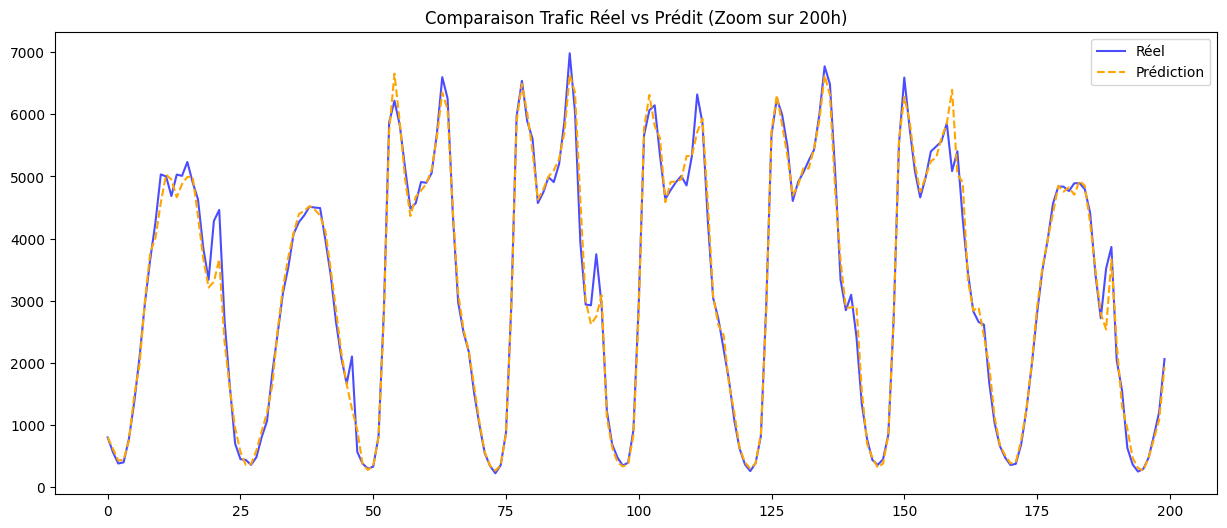

In [21]:
# 7. VISUALISATION DES RÉSULTATS
plt.figure(figsize=(15, 6))
plt.plot(y_test.values[:200], label="Réel", color='blue', alpha=0.7)
plt.plot(predictions[:200], label="Prédiction", color='orange', linestyle='--')
plt.title("Comparaison Trafic Réel vs Prédit (Zoom sur 200h)")
plt.legend()
plt.show()

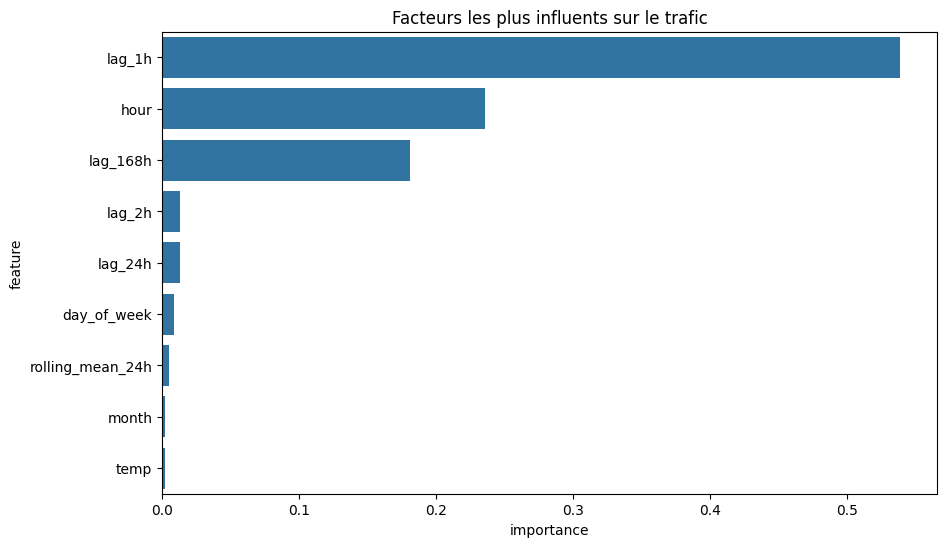

In [22]:
# 8. IMPORTANCE DES VARIABLES
importance_df = pd.DataFrame({'feature': features, 'importance': model.feature_importances_})
importance_df = importance_df.sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=importance_df)
plt.title("Facteurs les plus influents sur le trafic")
plt.show()


In [23]:
# Sauvegarde pour Streamlit
import joblib
joblib.dump(model, 'traffic_model.pkl')
joblib.dump(features, 'features_list.pkl')

['features_list.pkl']